# ResNet training
This notebook trains an ResNet model for multi-class classification on the ERCP dataset.

In [1]:
import os
import numpy as np
import random
import time

import torch
import seaborn as sns

%matplotlib inline
import matplotlib.pyplot as plt

from PIL import Image

from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

from torch import nn
from torch.utils.data import Dataset
from torchmetrics.classification import MulticlassF1Score
from torchvision import models

from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.transforms import (
    Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
    RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
    ToTensor, Compose, NormalizeIntensity, Lambda,
    CropForeground, CenterSpatialCrop, ScaleIntensityRangePercentiles
)
from monai.utils import set_determinism

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

print_config()

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP_modulo2/MIQR-CC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP_modulo2/MIQR-CC/.venv/lib/python3.12/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


MONAI version: 1.5.2
Numpy version: 2.4.4
Pytorch version: 2.11.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /Users/<username>/Workspace/Simb/mia/2-semestre/trabalhos/AP_modulo2/MIQR-CC/.venv/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.26.0
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.2
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 1.27.0
pynr

In [2]:
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_name = os.path.join(MODEL_DIR, 'resnet50_v3.pth')

In [3]:
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

def set_seed(seed=42):
    set_determinism(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [4]:
base_dir = './dataset_clahe'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


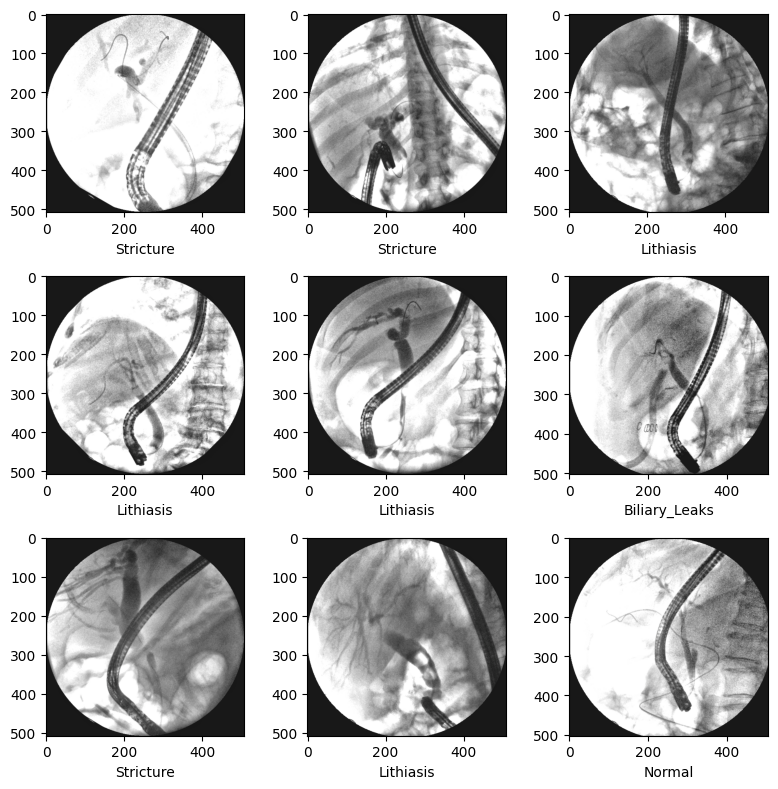

In [5]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()

----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


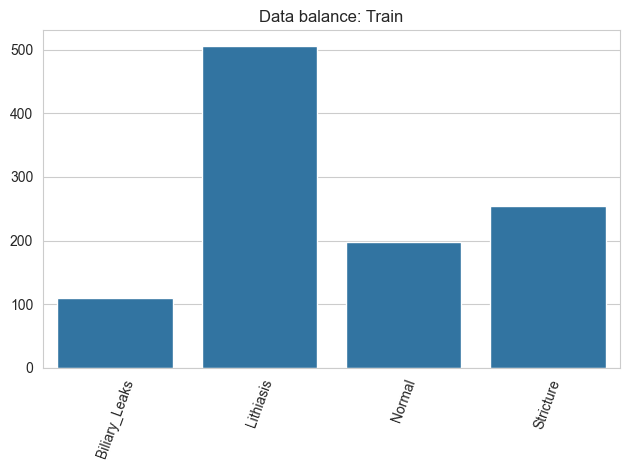

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


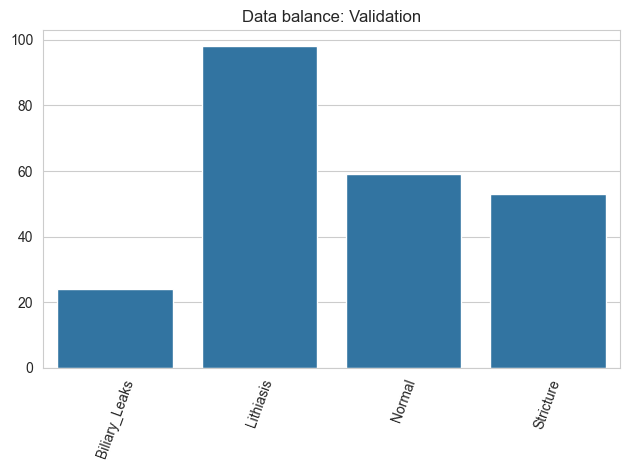

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


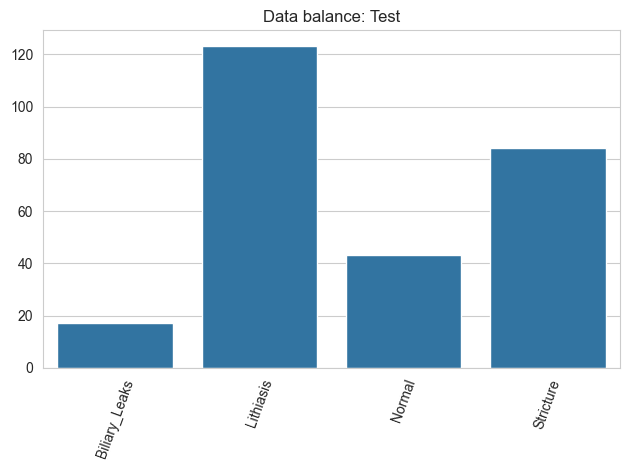

In [6]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')

## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 512×512.

In [7]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

def mask_circular_field(img):
    # img shape: C, H, W
    _, h, w = img.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, device=img.device),
        torch.arange(w, device=img.device),
        indexing="ij"
    )
    cy, cx = h / 2.0, w / 2.0
    radius = 0.60 * min(h, w)
    mask = ((yy - cy) ** 2 + (xx - cx) ** 2) <= (radius ** 2)
    return img * mask.unsqueeze(0).to(img.dtype)

CENTER_ROI = 480
BLACK_THRESHOLD = 15

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    CropForeground(select_fn=lambda x: x > BLACK_THRESHOLD, margin=0),
    CenterSpatialCrop(roi_size=(CENTER_ROI, CENTER_ROI)),
    ScaleIntensityRangePercentiles(lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True),
    Lambda(mask_circular_field),
    Resize((512, 512)),
    RandRotate(range_x=5, prob=0.25),
    RandZoom(min_zoom=0.95, max_zoom=1.05, prob=0.25),
    RandAdjustContrast(prob=0.2, gamma=(0.9, 1.1)),
    RandGaussianNoise(prob=0.15, mean=0.0, std=0.005),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    CropForeground(select_fn=lambda x: x > BLACK_THRESHOLD, margin=0),
    CenterSpatialCrop(roi_size=(CENTER_ROI, CENTER_ROI)),
    ScaleIntensityRangePercentiles(lower=1, upper=99, b_min=0.0, b_max=1.0, clip=True),
    Lambda(mask_circular_field),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [8]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

## Model
Instantiate an ResNet backbone (pretrained) and adapt the classifier head to the number of classes.

In [9]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.fc.in_features, num_class)
)
model = model.to(device)

## Training
The `train_model` function runs the training loop with optional early stopping, learning rate scheduling and logging of metrics (F1, AUC). Parameters and training logic are unchanged.

In [10]:

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    # F1 metric
    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            #outputs = torch.softmax(outputs, dim=1)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        # Compute F1-score on training set
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()  # Train F1

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                #outputs = torch.softmax(outputs, dim=1)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            # Compute F1-score on validation set
            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()   
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0  # reset counter
            else:
                epochs_without_improvement += 1
            
            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
        
        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()

        scheduler.step() 

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


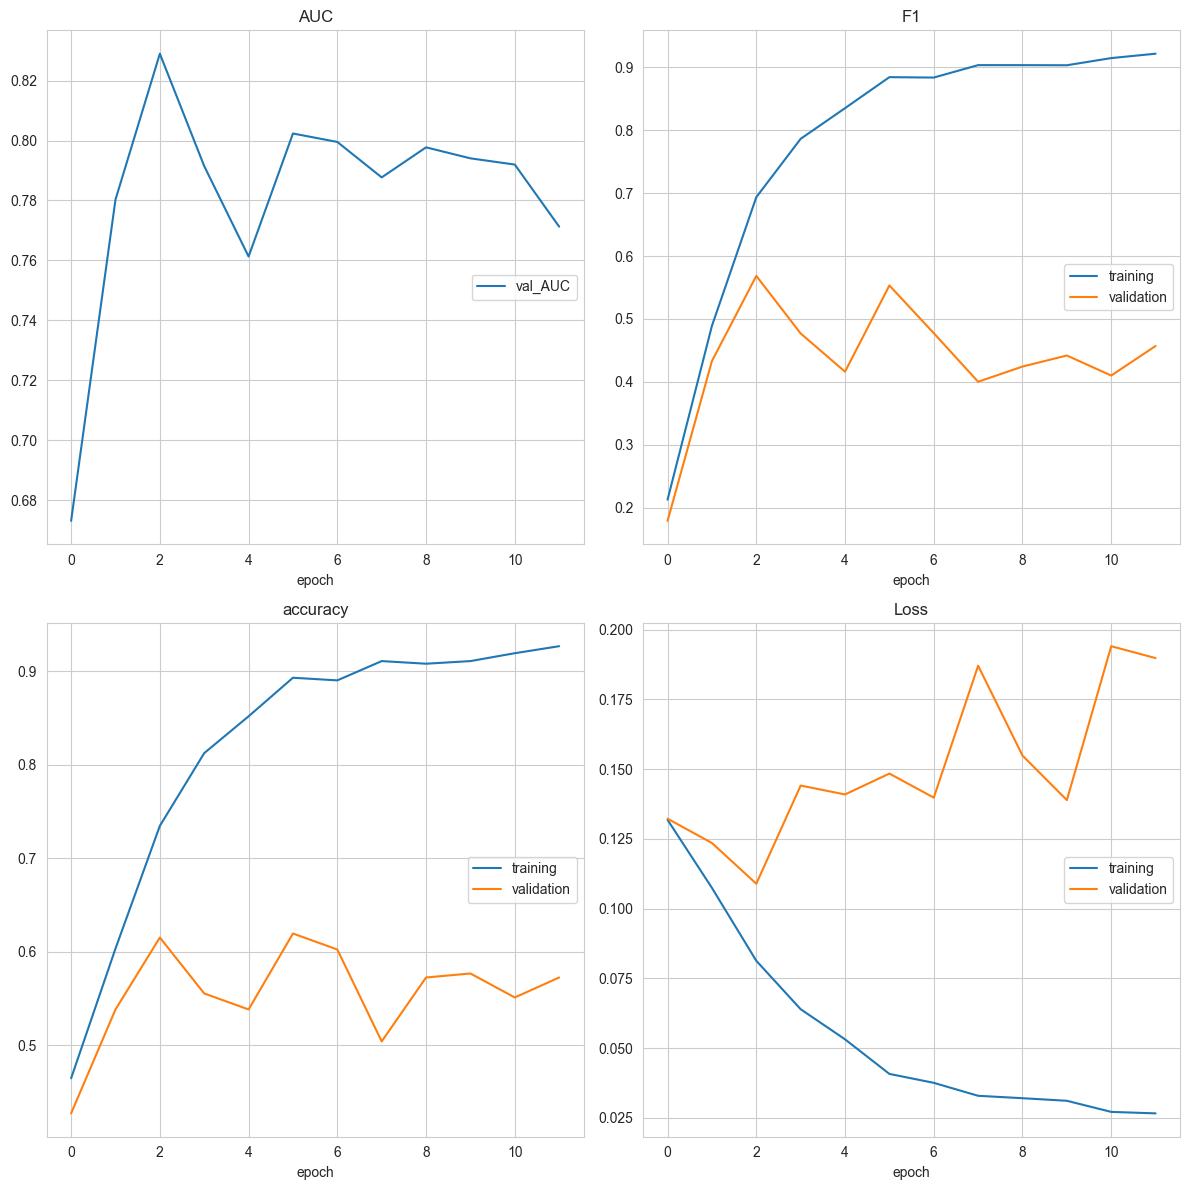

Early stopping at epoch 13 
 Best Val F1: 0.5685 
 Best Train F1: 0.6935 
 current Val F1: 0.4326 
 current Train F1: 0.9491 
 Best epoch: 3 

train completed, best_metric: 0.5685 at epoch: 3
Time elapsed: 1468.654924915987 seconds


In [11]:
EPOCHS = 60
LEARNING_RATE = 1e-4

from monai.losses import FocalLoss
loss_function = FocalLoss(to_onehot_y=True)

optimizer = torch.optim.Adam(model.parameters(), LEARNING_RATE)

val_interval = 1
auc_metric = ROCAUCMetric()

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Time elapsed: {endtime - starttime} seconds")

## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix. The following cells perform inference and generate the final metrics and plots.

F1 Score: 0.6898
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [3]
true: [0] pred: [2]
true: [0] pred: [2]
Accuracy: 0.749

correct: 4 incorrect: 7
Accuracy: 0.749

correct: 4 incorrect: 7
F1 Score: 0.6898
               precision    recall  f1-score   support

Biliary_Leaks     0.7778    0.4118    0.5385        17
    Lithiasis     0.7615    0.8049    0.7826       123
       Normal     0.5849    0.7209    0.6458        43
    Stricture     0.8400    0.7500    0.7925        84

     accuracy                         0.7491       267
    macro avg     0.7411    0.6719    0.6898       267
 weighted avg     0.7588    0.7491    0.7481       267

[[ 7  1  8  1]
 [ 2 99 13  9]
 [ 0 10 31  2]
 [ 0 20  1 63]]


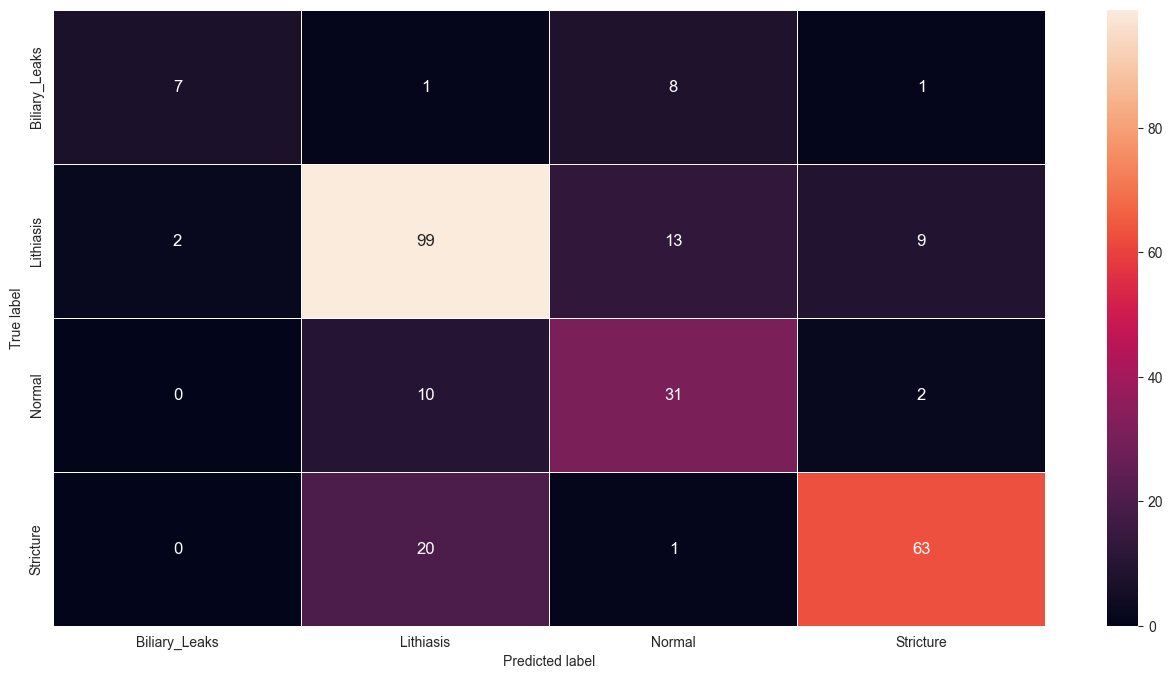

In [13]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    
    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  # Can be 'micro', 'macro' or 'weighted'
    print(f"F1 Score: {f1:0.4f}")
    
    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

# Load trained model
model.load_state_dict(torch.load('./' + model_name))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name)

/var/folders/vr/cfj8s1zj0r32n7cdxsst8bg80000gn/T/ipykernel_348/4074077696.py:119: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vr/cfj8s1zj0r32n7cdxsst8bg80000gn/T/ipykernel_348/4074077696.py:119: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP_modulo2/MIQR-CC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP_modulo2/MIQR-CC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


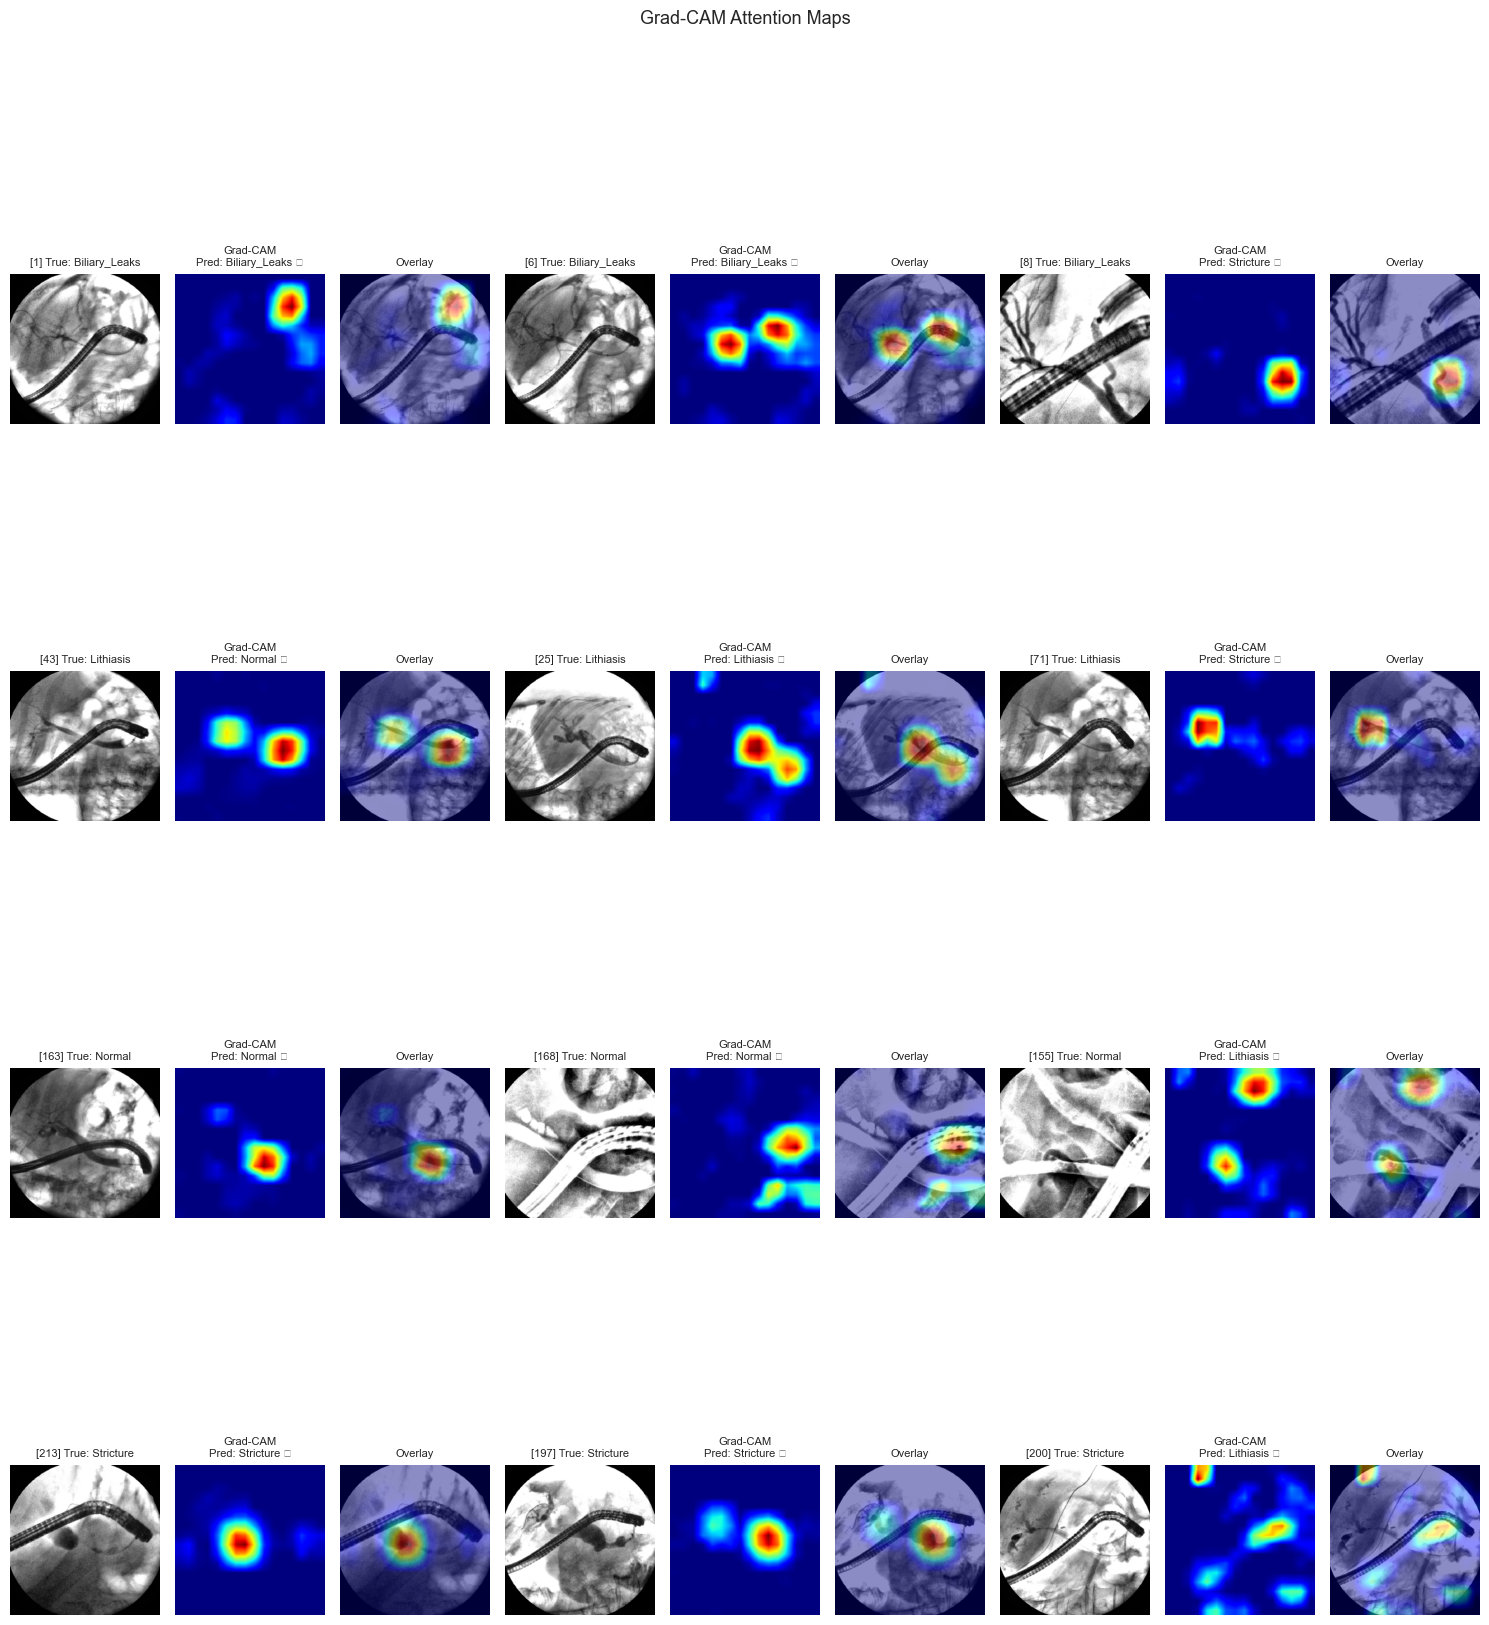

In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm


def grad_cam(model, input_tensor, target_class=None, target_layer=None):
    """
    Compute a Grad-CAM heatmap for `input_tensor` (1, C, H, W).

    Parameters
    ----------
    model         : trained model (eval mode)
    input_tensor  : (1, C, H, W) tensor on the same device as the model
    target_class  : class index to explain; if None uses the predicted class
    target_layer  : nn.Module to hook; defaults to model.layer4[-1]

    Returns
    -------
    cam  : (H_in, W_in) numpy array in [0, 1]
    pred : predicted class index
    """
    if target_layer is None:
        target_layer = model.layer4[-1]

    activations, gradients = {}, {}

    fwd = target_layer.register_forward_hook(
        lambda m, i, o: activations.update({'feat': o})
    )
    bwd = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.update({'feat': go[0]})
    )

    model.eval()
    output = model(input_tensor)           # (1, num_classes)
    pred = int(output.argmax(dim=1).item())

    if target_class is None:
        target_class = pred

    model.zero_grad()
    output[0, target_class].backward()

    fwd.remove()
    bwd.remove()

    # Global-average-pool the gradients over spatial dims → channel weights
    feats = activations['feat'].detach().cpu()    # (1, C, h, w)
    grads = gradients['feat'].detach().cpu()      # (1, C, h, w)
    weights = grads.mean(dim=(2, 3), keepdim=True)

    cam = F.relu((weights * feats).sum(dim=1)).squeeze(0)  # (h, w)

    # Upsample to input resolution
    H, W = input_tensor.shape[2], input_tensor.shape[3]
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    # Normalise to [0, 1]
    lo, hi = cam.min(), cam.max()
    cam = (cam - lo) / (hi - lo + 1e-8)

    return cam, pred


def show_grad_cam(model, dataset, indices, class_names, device, target_class=None, cols=3):
    """Visualise Grad-CAM for a list of sample indices."""
    n = len(indices)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 3, figsize=(5 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(rows, cols * 3)

    for plot_i, idx in enumerate(indices):
        row, col_group = divmod(plot_i, cols)
        ax_orig    = axes[row, col_group * 3]
        ax_cam     = axes[row, col_group * 3 + 1]
        ax_overlay = axes[row, col_group * 3 + 2]

        img_tensor, true_label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        heatmap, pred = grad_cam(model, input_tensor, target_class=target_class)

        # Prepare display image (C, H, W) → (H, W, C), normalised
        img_np = img_tensor.permute(1, 2, 0).numpy().astype(np.float32)
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        # Convert heatmap to RGB and blend
        heat_rgb = mplcm.jet(heatmap)[:, :, :3]
        overlay  = np.clip(0.55 * img_np + 0.45 * heat_rgb, 0, 1)

        # Check if image is grayscale-repeated (3 identical channels)
        is_gray = np.allclose(img_np[:, :, 0], img_np[:, :, 1])
        img_show = img_np[:, :, 0] if is_gray else img_np

        correct = "✓" if pred == true_label else "✗"
        ax_orig.imshow(img_show, cmap='gray' if is_gray else None)
        ax_orig.set_title(f"[{idx}] True: {class_names[true_label]}", fontsize=8)
        ax_orig.axis('off')

        ax_cam.imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        ax_cam.set_title(f"Grad-CAM\nPred: {class_names[pred]} {correct}", fontsize=8)
        ax_cam.axis('off')

        ax_overlay.imshow(overlay)
        ax_overlay.set_title("Overlay", fontsize=8)
        ax_overlay.axis('off')

    # Hide unused axes
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        for k in range(3):
            axes[r, c * 3 + k].axis('off')

    plt.suptitle("Grad-CAM Attention Maps", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# --- Visualise 9 test samples (3 per class if possible) ---
model.eval()
np.random.seed(0)

# Sample indices grouped by class for balanced visualisation
indices_per_class = {c: [] for c in range(num_class)}
for i, (_, lbl) in enumerate(test_ds):
    indices_per_class[lbl].append(i)

selected = []
samples_per_class = 3
for c in range(num_class):
    pool = indices_per_class[c]
    n = min(samples_per_class, len(pool))
    selected.extend(np.random.choice(pool, n, replace=False).tolist())

show_grad_cam(model, test_ds, selected, class_names, device)